In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

In [18]:
df = pd.read_csv(r"../../data/LeafRiverDaily.csv")


L = df.shape[0]

df

,Precipitation,Temperature,Streamflow
0,0.0000,4.6004,0.289951
1,0.0000,4.3092,0.244761
2,0.0000,4.3286,0.213382
3,0.0000,4.7777,0.193298
4,0.0000,2.9110,0.183258
...,...,...,...
10955,0.0000,3.1170,0.144348
10956,0.0000,2.6248,0.148112
10957,0.0000,4.9893,0.148466
10958,0.0000,4.5724,0.142589


In [19]:
def NSE(observations, simulations):
    obs = np.asarray(observations)
    sims = np.asarray(simulations)
    mask = np.isfinite(obs) & np.isfinite(sims)
    obs = obs[mask]
    sims = sims[mask]
    denominator = np.sum((obs-np.mean(obs))**2)
    if denominator == 0:
        return np.nan
    else:
        return 1 - (np.sum((obs-sims)**2) / denominator)

In [20]:
def make_ode(time_vals, P, T, a, b, c, S_0=0):
    """
    param: t_time: time in days
    param: P: Precipitation in mm
    param: T: Temperature in C
    param: a: optimization coeff. a - evapotranspiration
    param: b: optimization coeff. b - discharge
    param: c: optimization coeff. c - storage-discharge non-linearity
    """

    P_of_t = interp1d(time_vals, P, kind="linear", fill_value="extrapolate")
    T_of_t = interp1d(time_vals, T, kind="linear", fill_value="extrapolate")

    def ode(t, S):
        S = max(S[0], 0)
        temp = float(T_of_t(t))

        return [float(P_of_t(t)) - (a * max(temp, 0)) - b * (S**c)]

    solution = solve_ivp(ode, t_span=(time_vals[0], time_vals[-1]), y0=[S_0], t_eval=time_vals, method="RK45")

    # print(solution)
    # print(type(solution.y[0]))
    # print(solution.y[0].shape)


    S_t = np.maximum(solution.y[0], 0.0)

    # print(S_t.shape)

    Q_new = b * S_t**c
    return S_t, Q_new
    # return True, True

In [21]:
extraction = 90 # from problem 2
x_size = 10870 # From problem 2
train_cut = int(0.8 * x_size)


train_s = extraction
train_f = extraction + train_cut
test_s = train_f
test_f = len(df)

t_all = np.arange(len(df))
P_all = df["Precipitation"].to_numpy()
T_all = df["Temperature"].to_numpy()
Q_all = df["Streamflow"].to_numpy()


t_train, P_train, T_train, Q_train = t_all[train_s:train_f], P_all[train_s:train_f], T_all[train_s:train_f], Q_all[train_s:train_f]

t_test, P_test, T_test, Q_test  = t_all[test_s:test_f], P_all[test_s:test_f], T_all[test_s:test_f], Q_all[test_s:test_f]

In [22]:
results = np.load("results.npy", allow_pickle=True)
best_data = np.load("best_params.npz")

best_a = float(best_data["a"])
best_b = float(best_data["b"])
best_c = float(best_data["c"])
train_mse = float(best_data["train_mse"])

_, q_test_sim = make_ode(t_test, P_test, T_test, best_a, best_b, best_c, S_0=1.0)

In [23]:
x, y = [], []

for i in range(extraction, L):
    x_past = df.loc[i-extraction:i-1, ["Precipitation", "Temperature"]].values
    x.append(x_past.flatten())
    y_current = df.loc[i, 'Streamflow']
    y.append(y_current)

x = np.array(x)
y = np.array(y)

print(len(x))
print(y)


x_size = len(x)
train_cut = int(0.8 * x_size)

PT_train = x[:train_cut]
PT_test = x[train_cut:]
Q_train = y[:train_cut]
Q_real = y[train_cut:]

model = LinearRegression()
model.fit(PT_train, Q_train)

Q_pred = model.predict(PT_test)

10870
[3.753023   3.4266755  2.974805   ... 0.14846631 0.14258865 0.1387234 ]


NSE (Linear Regression): 0.6948791154544853
NSE (SCE Model):  0.27846648783015127


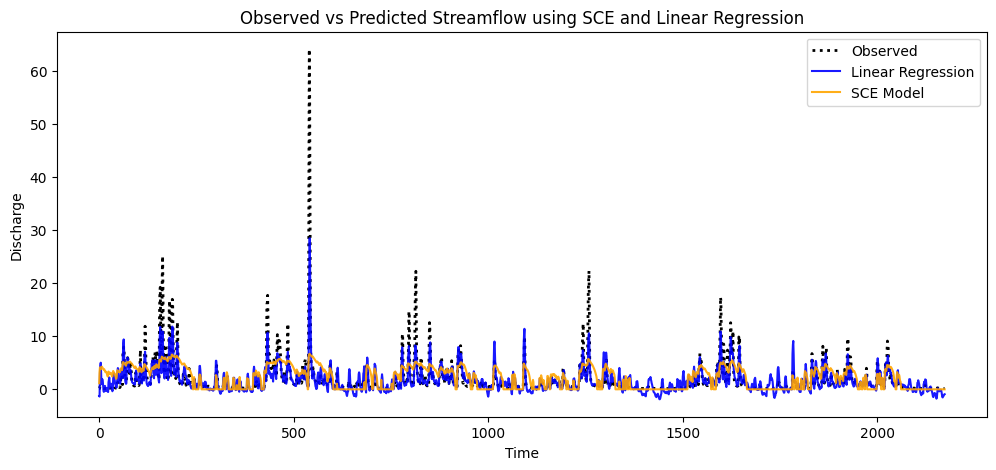

In [32]:
n = min(len(Q_pred), len(q_test_sim), len(Q_test))
obs = np.asarray(Q_test[:n])
pred_lr = np.asarray(Q_pred[:n])
pred_sce = np.asarray(q_test_sim[:n])

nse_lr = NSE(obs, pred_lr)
nse_sce = NSE(obs, pred_sce)

print(f"NSE (Linear Regression): {nse_lr}")
print(f"NSE (SCE Model):  {nse_sce}")


plt.figure(figsize=(12,5))
plt.plot(obs, label="Observed", color="black", linestyle=":", linewidth=2)
plt.plot(pred_lr, label=f"Linear Regression", color='blue', alpha=0.9)
plt.plot(pred_sce, label=f"SCE Model", color='orange', alpha=0.9)
plt.xlabel("Time")
plt.ylabel("Discharge")
plt.title("Observed vs Predicted Streamflow using SCE and Linear Regression")
plt.legend()
plt.show()

In terms of NSE, the linear regression substantially does better than the SCE model (0.69 > 0.28 - NSE's respectively). However, it should be noted that the SCE model was only run for 50 iterations, so running it for longer would probably result in the SCE doing better than the linear regression. The linear regression does best in situations where the signal-to-noise ratio is high and the data volume is limited in scope. However, it can run into problems with modeling outlier events and doesn't show nonlinear thresholds well. This is where SCE improves performance by utilizing global searching techniques. SCE still has some shortcomings as it is much more computationally intensive and takes longer than the linear regression.

If I were to improve these systems I would try to make a more accurate linear regression model for the river by adding in other parameters besides just temperature, precipitation, and streamflow. For example, we could've added ET measurements to improve the regression. To improve the SCE I would first start by doing many more iterations than the 50 I was able to complete in this assignment as more iterations gets the end result closer to "perfectly" accurate. Also, I would explore other "objective functions" as I may not have chosen the best for this use case.
